<a href="https://colab.research.google.com/github/RazyAnas/MachineLearning/blob/main/IQR_Method_Outlier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IQR method
when to use: When skewed data

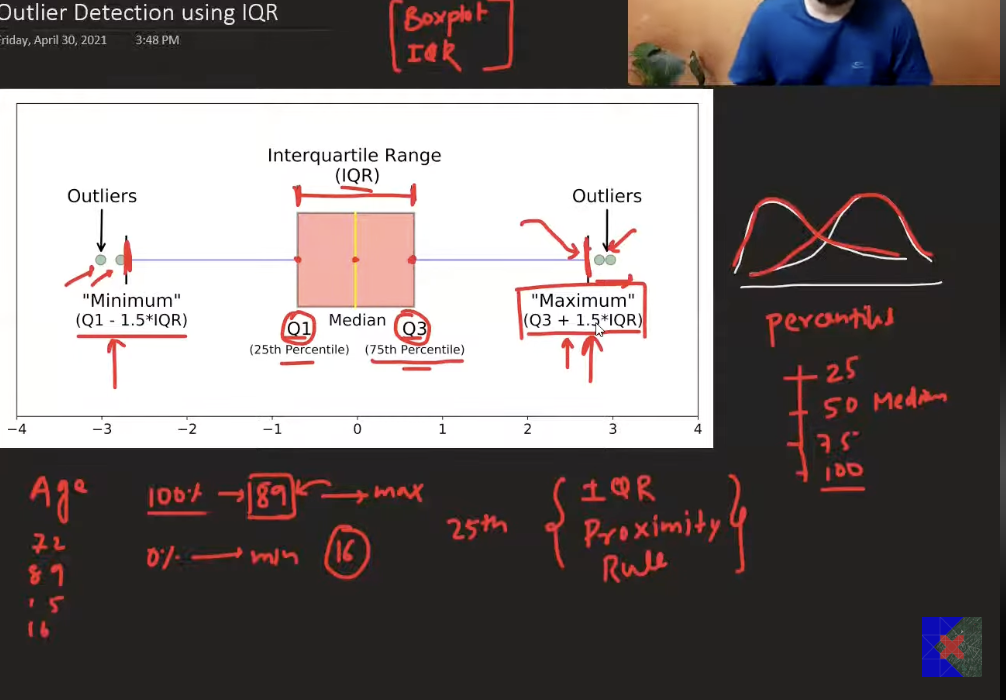

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day43-outlier-removal-using-iqr-method/placement.csv')

In [5]:
df.shape

(1000, 3)

In [7]:
df.sample(5)

,cgpa,placement_exam_marks,placed
758,6.55,29.0,0
654,7.03,76.0,0
473,6.38,25.0,0
559,6.61,58.0,1
354,6.73,23.0,1


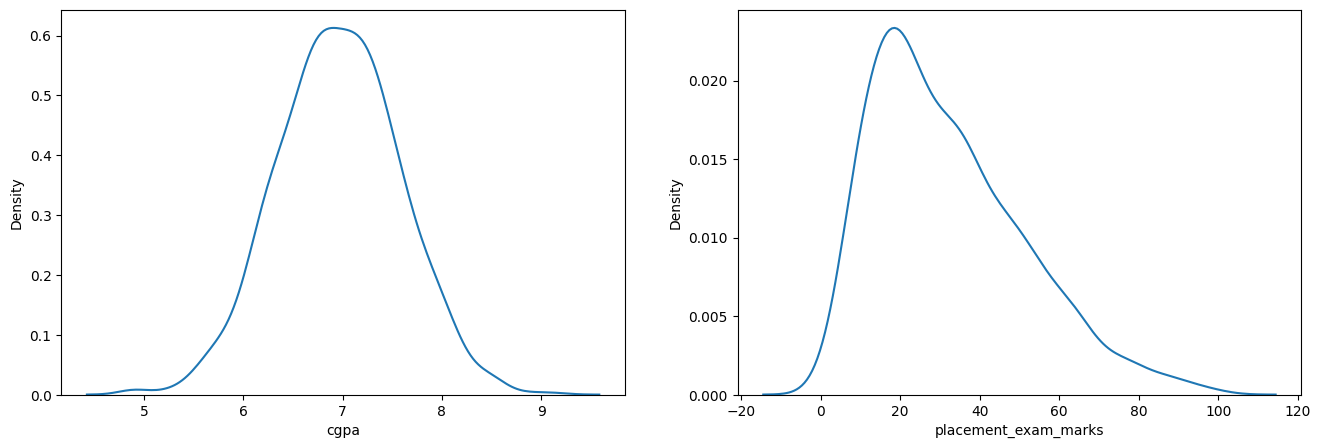

In [8]:
plt.figure(figsize=(16,5))
plt.subplot(121)

sns.kdeplot(df['cgpa'])

plt.subplot(122)
sns.kdeplot(df['placement_exam_marks'])

plt.show()

In [11]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [14]:
df['placement_exam_marks'].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


<Axes: xlabel='placement_exam_marks'>

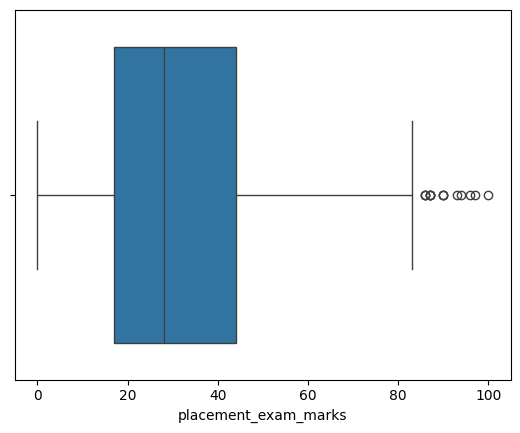

In [17]:
sns.boxplot(df['placement_exam_marks'],orient='h')

In [18]:
# Returns 25th, 50th (median), and 75th percentiles
percentile25, percentile75 = df['placement_exam_marks'].quantile([0.25, 0.75])


In [19]:
percentile25

17.0

In [20]:
percentile75

44.0

In [21]:
iqr = percentile75 - percentile25

In [22]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

# Finding Outliers

In [23]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


# Trimming

In [27]:
new_df = df[df[ 'placement_exam_marks'] < upper_limit]

In [28]:
new_df.shape

(985, 3)

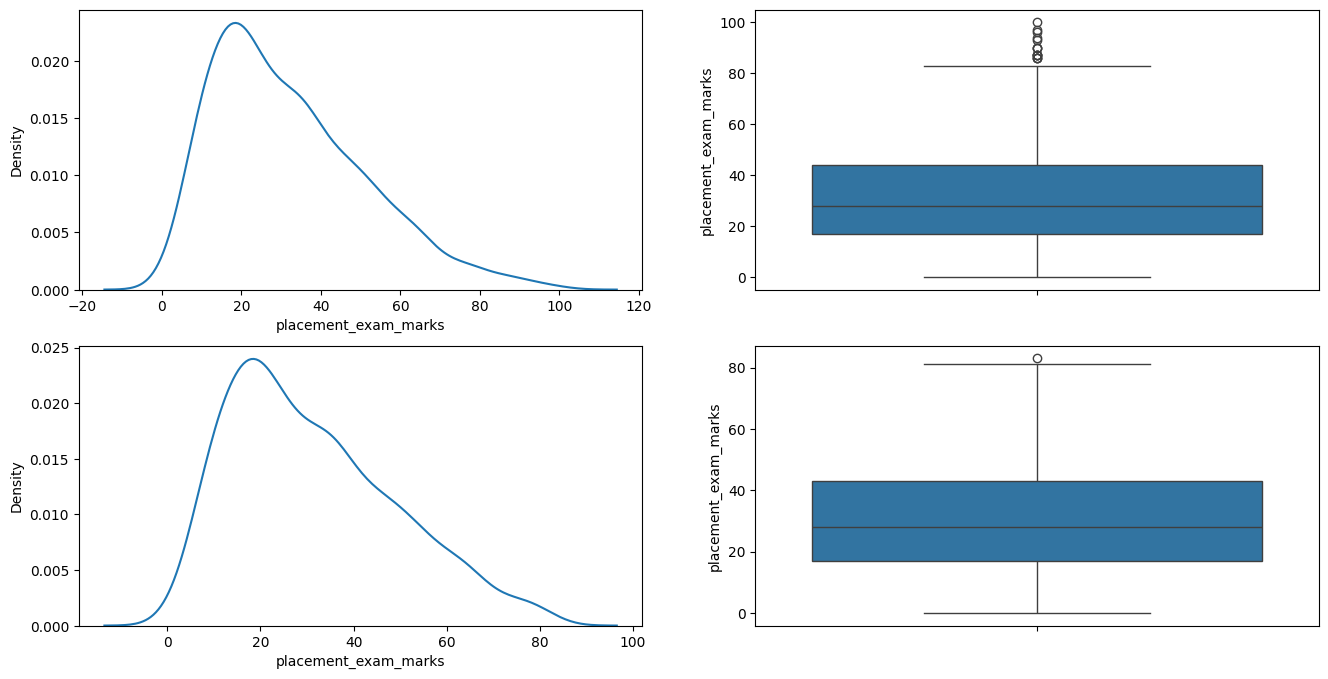

In [29]:
# Comparing
plt.figure(figsize=(16,8))

plt.subplot(221)
sns.kdeplot(df['placement_exam_marks'])

plt.subplot(222)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(223)
sns.kdeplot(new_df['placement_exam_marks'])

plt.subplot(224)
sns.boxplot(new_df['placement_exam_marks'])


plt.show()

# Capping

In [32]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [ ]:
# np.where(condition, true wala func, false wala func)

In [33]:
new_df_cap.shape

(1000, 3)

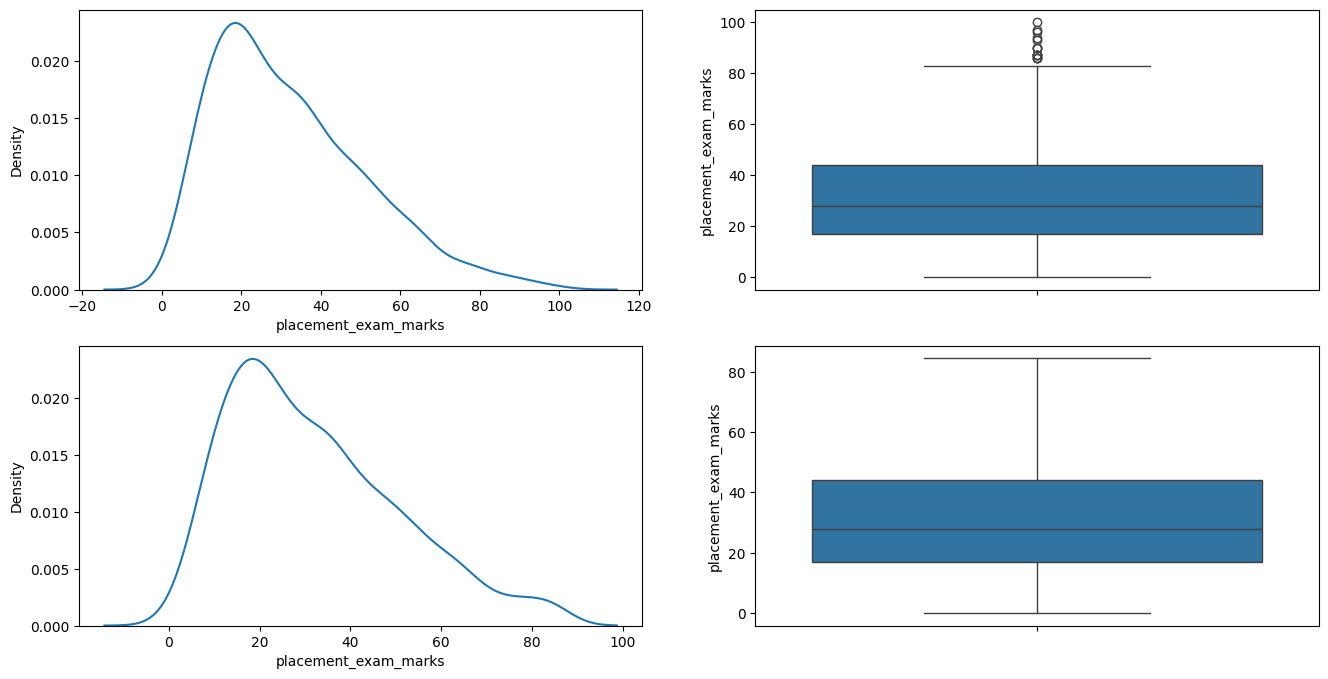

In [34]:
# Comparing
plt.figure(figsize=(16,8))

plt.subplot(221)
sns.kdeplot(df['placement_exam_marks'])

plt.subplot(222)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(223)
sns.kdeplot(new_df_cap['placement_exam_marks'])

plt.subplot(224)
sns.boxplot(new_df_cap['placement_exam_marks'])


plt.show()